In [1]:
import pickle
import os
import gpflow
import numpy as np
f64 = gpflow.utilities.to_default_float
import matplotlib.pylab as plt
import pandas as pd
import bambi as bmb
from matplotlib.ticker import MaxNLocator


In [2]:
for c in range(7):
    globals()[f'particles_summary{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/particles_summary{c}.pkl", mode="rb"))
    globals()[f'threshold{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/threshold{c}.pkl", mode="rb"))
    globals()[f'weight{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/weight{c}.pkl", mode="rb"))
    globals()[f'index{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/p_index_{c}.pkl", mode="rb"))
    globals()[f'mad{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/mad{c}.pkl", mode="rb"))
    globals()[f'r_s_mean{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/r_s_mean{c}.pkl", mode="rb"))
    globals()[f'r_s_median{c}'] = np.load(open(file = os.getcwd()+f"/ABC_details/glmsep/r_s_median{c}.pkl", mode="rb"))

mad_all = np.vstack([globals()[f'mad{i}'] for i in range(7)])
threshold_all = np.vstack([globals()[f'threshold{i}'] for i in range(7)])
r_s_mean = np.vstack([globals()[f'r_s_mean{i}'] for i in range(7)])
r_s_median = np.vstack([globals()[f'r_s_median{i}'] for i in range(7)])

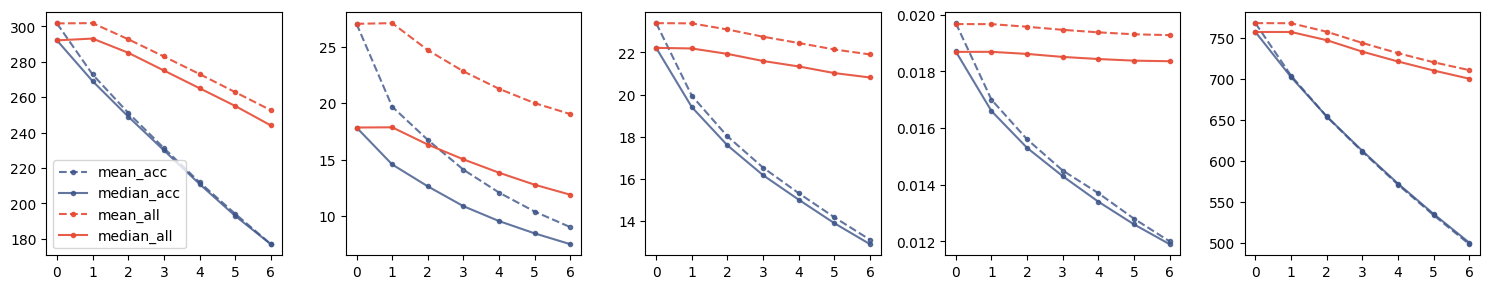

In [3]:
fig = plt.figure(figsize=(15, 3))
for j in range(5):
    ax = fig.add_subplot(1, 5, j+1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    m0 = []
    m1 = []
    m2 = []
    for i in range(7):
        m0.append(np.round(np.nanmean(globals()[f'particles_summary{i}'][:, j]), 4))
        m1.append(np.round(np.nanmedian(globals()[f'particles_summary{i}'][:, j]), 4))
    
    plt.plot(m0, '.--', label='mean_acc', color = '#3C5488', alpha=0.8)
    plt.plot(m1, '.-', label='median_acc', color = '#3C5488', alpha=0.8)

    plt.plot(r_s_mean[:, j], '.--', label='mean_all', color = '#E64B35', alpha=0.9)
    plt.plot(r_s_median[:, j], '.-', label='median_all', color = '#E64B35', alpha=0.9) 

    if j == 0: 
        plt.legend(fontsize=10)
plt.tight_layout()
# plt.savefig('plot11.pdf')  

plt.show()

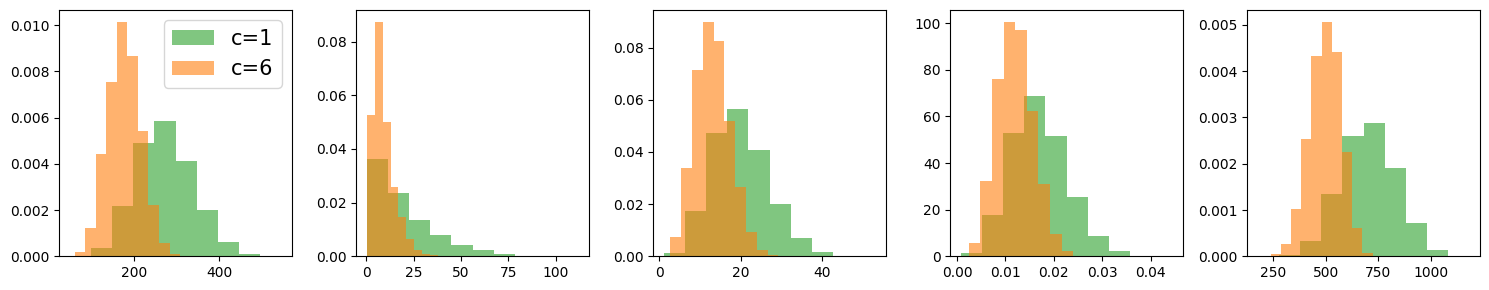

In [4]:
fig = plt.figure(figsize=(15, 3))
for j in range(5):
    ax = fig.add_subplot(1, 5, j+1)

    plt.hist(globals()[f'particles_summary{1}'][:, j], color = f'C{2}', density=True, alpha=0.6, label=f'c={1}')
    plt.hist(globals()[f'particles_summary{6}'][:, j], color = f'C{1}', density=True, alpha=0.6, label=f'c={6}')
    if j == 0: plt.legend(fontsize=15)
plt.tight_layout()

In [5]:
for c in range(7):
    print(globals()[f'threshold{c}'])

11.511275429202463
10.225517772136444
9.531465984147214
8.96705376259319
8.37982149619425
7.841506773588512
7.171797251868548


In [6]:
# the number of neighbours
for c in range(1, 7):
    neighbour =[] 
    current_index_simu = globals()[f'index{c}']
    for kk in range(current_index_simu.shape[0]): 
        neighbour.append(np.sum(np.sum(current_index_simu[kk] == current_index_simu, axis=1) >= 4)-1)

    print(np.sum(np.array(neighbour) > 0))

64858
28965
21966
11572
3496
1183


In [7]:
# number of uniques
800014
501878
252981
151058
80506
30315

30315

In [8]:
#lb1
print((800014 - 0)*5*5000) 
print((501878 - 64858)*5*5000) 
print((252981 - 28965)*5*5000) 
print((151058 - 21966)*5*5000) 
print((80506- 11572)*5*5000) 
print((30315 - 3496)*5*5000)

20000350000
10925500000
5600400000
3227300000
1723350000
670475000


In [9]:
for c in range(7):
    print(1 / np.sum(globals()[f'weight{c}'] ** 2))

800013.9999999992
501884.99999999953
251110.75406642488
147622.53633820848
77834.30544334467
28664.962886904417
9333.732182895203


In [10]:
#lb2 
print((800013.9999999992- 0)*5*5000) 
print((501884.99999999953 - 64858)*5*5000) 
print((251110.75406642488 - 28965)*5*5000) 
print((147622.53633820848 - 21966)*5*5000) 
print((77834.30544334467- 11572)*5*5000) 
print((28664.962886904417 - 3496)*5*5000)

20000349999.99998
10925674999.999989
5553643851.660622
3141413408.455212
1656557636.0836165
629224072.1726105


In [11]:
# acc rate
print(501885 /910000)
print(252981/800000)
print(151059/860000)
print(80510/890000)
print(30315/710000)
print(10022/570000)
p_acc = [1, 501885 /910000, 252981/800000, 151059/860000, 80510/890000, 30315/710000,10022/570000]


0.551521978021978
0.31622625
0.17565
0.09046067415730337
0.04269718309859155
0.017582456140350877


In [12]:
p_prior = [1]
number_prior = [particles_summary0.shape[0]]
for i in range(1, 7):
    p_prior.append(np.mean(np.sqrt(np.sum((particles_summary0/globals()[f'mad{i-1}'])**2, axis=1)) < globals()[f'threshold{i-1}']))
    number_prior.append(np.sum(np.sqrt(np.sum((particles_summary0/globals()[f'mad{i-1}'])**2, axis=1)) < globals()[f'threshold{i-1}']))

t_c = np.array([87.23, 107.48, 93.15, 98.77, 101.97, 81.08, 64.67 ])
cum_t_c = np.cumsum(t_c)
N_c = np.array([800014, 501885, 252981, 151059, 80510, 30315,10022])
E_c1 = number_prior * (cum_t_c / 87.23)
E_c2 = number_prior * (t_c / 87.23)
t_E = (N_c/number_prior) * 87.23

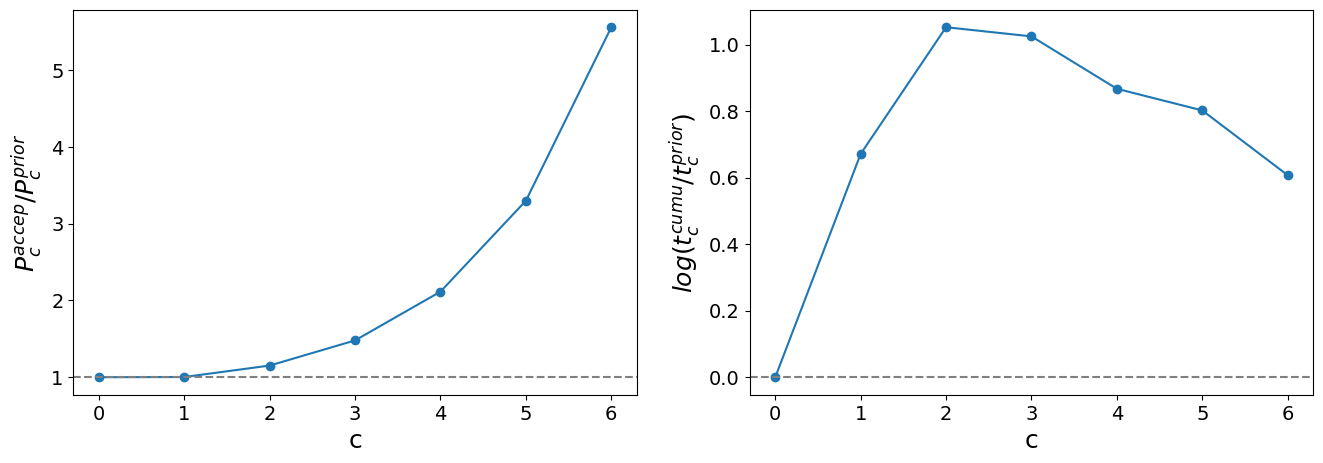

In [16]:
fig = plt.figure(figsize=(16, 5))
ax = fig.add_subplot(1, 2, 1)

plt.plot(np.array(p_acc)/np.array(p_prior), '-o')
plt.ylabel(r"$P^{accep}_c"+"     /       " +r"P_{c}^{prior}$", fontsize=18)
plt.xlabel('c', fontsize=18)
plt.axhline(1, linestyle='--', color='grey')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax = fig.add_subplot(1, 2, 2)

plt.plot(np.log(cum_t_c/t_E), '-o')
# plt.plot(N_c/E_c2, '-o')
plt.ylabel(r"$log(t^{cumu}_c"+"     /       " +r"t_{c}^{prior})$", fontsize=18)
plt.xlabel('c', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.axhline(0, linestyle='--', color='grey')
# plt.savefig('plot13.pdf')  
